# Supplementary figures
Remake figures 4 and 6 with output from Morrison simulations

In [1]:
import pandas as pd
import xarray as xr
import datetime as dt
import numpy as np
import utils
import wrfpp
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from glob import glob
import seaborn as sns
import string

# Read measurement data

In [2]:
def read_mosaic_aero_mass(fname, header, species, columns, flag_label, tslice, freq):
    data = pd.read_csv(fname, header=header, sep="\t")
    data["Date/Time"] = pd.to_datetime(data["Date/Time"])
    data = data.set_index("Date/Time").to_xarray()
    data = data.rename(columns)
    data = data.sel(time=tslice)

    data_resample = data.resample(time=freq).mean()
    data_resample = data_resample[species]

    data_masked = data[species].where(data[flag_label]!=1)
    data_masked_resample = data_masked.resample(time=freq).mean()
    
    return data_resample, data_masked_resample

In [3]:
apr = slice(dt.datetime(2020,4,10), dt.datetime(2020,4,20))

ams_columns = {  # used for cleaner column names
    'Date/Time': 'time',
    'Latitude': 'lat',
    'Longitude': 'lon',
    '[SO4]2- [µg/m**3]': 'so4',
    '[NO3]- [µg/m**3]': 'no3',
    '[NH4]+ [µg/m**3]': 'nh4',
    'Cl- [µg/m**3]': 'cl',
    'Org aerosol [µg/m**3]': 'org',
    'QF [NH4]+': 'nh4_qc',  # 1=good, 0=bad
    'Flag pollution': 'pollution_qc'  # 1=polluted, 0=non polluted
}
flag = "pollution_qc"
ams_fname = "/mnt/data/mosaic/AMS_5species_noscaling.tab"
ams_data_1h, ams_masked_1h = read_mosaic_aero_mass(ams_fname, 51, ["so4","org"], ams_columns, flag, apr, "1h")

ebc_columns = {
    'Date/Time': 'time',
    'Latitude': 'lat',
    'Longitude': 'lon',
    'eBC [ng/m**3]': 'ebc',
    'Flag pollution': 'pollution_qc'  # 1=polluted, 0=non polluted
}
ebc_fname = "/mnt/data/mosaic//MOSAiC_eBC.tab"
ebc_data_1h, ebc_masked_1h = read_mosaic_aero_mass(ebc_fname, 42, "ebc", ebc_columns, flag, apr, "1h")


In [4]:
mosaic_met = xr.open_dataset("/mnt/data/mosaic/jozef_lower_atmos/MOSAiC_Atm_Properties.nc")
mosaic_met = mosaic_met.sel(time=apr)

# Read model output

In [5]:
apr = slice(dt.datetime(2020,4,1), dt.datetime(2020,4,30,23,59))

simulations = {
    "MORR2MOM": {
        "microphysics": "Morrison",
        "pollution_state": "polluted",
    },
    "MORR2MOM_NO_ANTHRO_NO_FIRES": {
        "microphysics": "Morrison",
        "pollution_state": "clean",
    }
}

wrfout = []
for sim,meta in simulations.items():
    ds_sim = xr.open_mfdataset(glob(f"/mnt/data/model_output/{sim}/*_mosaic.nc")).sel(Time=apr)
    ds_sim = ds_sim.expand_dims({
        "simulation": [sim]
    })
    ds_sim = ds_sim.assign_coords({
        "pollution_state": ("simulation",[meta["pollution_state"]]),
    })
    wrfout.append(ds_sim)
wrfout = xr.concat(wrfout, dim="simulation")
wrfout["rho_air"] = wrfout.wrf.density_of_dry_air[:]
wrfout["air_temperature"] = wrfout.wrf.air_temperature[:]
wrfout["altitude"] = wrfout.wrf.altitude_asl_c[:]
wrfout["box_depth"] = ((wrfout.wrf.altitude_asl[:]).rename({"bottom_top_stag":"bottom_top"})).diff("bottom_top")
wrfout_cld = xr.Dataset()
wrfout_cld["sfc_rad"] = (wrfout.SWDNB - wrfout.SWUPB + wrfout.LWDNB - wrfout.LWUPB).mean(["i","j"])
cdnc = 1e-6*(wrfout.QNDROP * wrfout.rho_air).where(wrfout.CLDFRA>0.1)/wrfout.CLDFRA
wrfout_cld["cdnc"] = cdnc.where((wrfout.altitude>=0)*(wrfout.altitude<2000)).mean(["bottom_top","i","j"])
wrfout_cld["clt_2km"] = 100*wrfout.CLDFRA.where((wrfout.altitude>=0)*(wrfout.altitude<2000)).max("bottom_top").mean(["i","j"])
wrfout_cld["lwp"] = 1e3*wrfout.wrf.cloud_liquid_water_path[:].mean(["i","j"])


/tmp/ipykernel_5891/1081789460.py:16: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_sim = xr.open_mfdataset(glob(f"/mnt/data/model_output/{sim}/*_mosaic.nc")).sel(Time=apr)
/tmp/ipykernel_5891/1081789460.py:16: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_sim = xr.open_mfdataset(glob(f"/mnt/data/model_output/{sim}/*_mosaic.nc")

## interpolate from WRF-Chem-Polar aerosol bins to PM1 size range

In [6]:
def make_bin_dimension(ds_wrf, species, nbins=4):
    aname, cwname = species+"_a", species+"_cw"

    # convert a0X output for this species to one array with new bin dimension
    aer_vars = [v for v in ds_wrf.data_vars if aname in v.lower()]
    array_aer = ds_wrf[aer_vars].to_array(dim="bin")
    array_aer["bin"] = np.arange(nbins)

    # cw0X variables
    cld_vars = [v for v in ds_wrf.data_vars if cwname in v.lower()]
    array_cld = ds_wrf[cld_vars].to_array(dim="bin")
    array_cld["bin"] = np.arange(nbins)

    # add new variables to new dataset
    ds_binned = xr.Dataset()
    ds_binned[species] = array_aer+array_cld

    # add bin size coordinates for new dimension
    [dlo, dmid, dhi] = utils.calc_mosaic_size_bins()    
    ds_binned = ds_binned.assign_coords({
        "Dlo": ("bin", dlo),
        "Dmid": ("bin", dmid),
        "Dhi": ("bin", dhi),
        "dD": ("bin", dhi-dlo)
    })

    return ds_binned

def sum_wrf_aero_bins(ds_binned, cutoff=1):
    if "bin" not in ds_binned.dims:
        msg = "[sum_wrf ERROR] no bin dimension on the dataset"
        raise ValueError(msg)
        return
    nbins = len(ds_binned.bin)
    bin_bounds = np.zeros((nbins+1))
    bin_bounds[:-1] = ds_binned.Dlo.values
    bin_bounds[-1] = ds_binned.Dhi.values[-1]

    # find size bin containing cutoff
    i = np.searchsorted(bin_bounds, cutoff)-1

    # sum up to cutoff
    ds_sum = ds_binned.isel(bin=slice(None,i)).sum(dim="bin")

    # add linear fraction of bin containing cutoff
    ibin_width = ds_binned.Dhi.values[i] - ds_binned.Dlo.values[i]
    f = (cutoff - ds_binned.Dlo.values[i]) / ibin_width
    ds_sum += f*ds_binned.isel(bin=i, drop=True)
    
    return ds_sum



In [7]:
wrfout["so4"] = wrfout.rho_air*sum_wrf_aero_bins(make_bin_dimension(wrfout, "so4")).so4
wrfout["bc"] = wrfout.rho_air*sum_wrf_aero_bins(make_bin_dimension(wrfout, "bc")).bc
wrfout["oc"] = wrfout.rho_air*sum_wrf_aero_bins(make_bin_dimension(wrfout, "oc")).oc
wrfout["toa"] = wrfout.rho_air*sum_wrf_aero_bins(make_bin_dimension(wrfout, "totoa")).totoa


In [8]:
apr10_20 = slice(dt.datetime(2020,4,10), dt.datetime(2020,4,20))
wrfout_mosaic_mean = wrfout.sel(Time=apr10_20).isel(simulation=wrfout.pollution_state=="polluted").mean(["i","j"]).squeeze()
wrfout_mosaic_min = wrfout.sel(Time=apr10_20).isel(simulation=wrfout.pollution_state=="polluted").min(["i","j"]).squeeze()
wrfout_mosaic_max = wrfout.sel(Time=apr10_20).isel(simulation=wrfout.pollution_state=="polluted").max(["i","j"]).squeeze()

In [9]:
cams = xr.open_dataset("/mnt/data/cams/cams_mosaic.nc").sel(time=apr)
cams_mosaic_mean = cams.mean(["i","j"])
cams_mosaic_min = cams.min(["i","j"])
cams_mosaic_max = cams.max(["i","j"])

cesm = xr.open_dataset("/mnt/data/cesm/cesm_mosaic.nc").sel(time=apr)
cesm_mosaic_mean = cesm.mean(["i","j"])
cesm_mosaic_min = cesm.min(["i","j"])
cesm_mosaic_max = cesm.max(["i","j"])

cams_mass_conc_mean = cams_mosaic_mean.interp(time=wrfout.Time) * wrfout_mosaic_mean.rho_air.isel(bottom_top=0)
cams_mass_conc_min = cams_mosaic_min.interp(time=wrfout.Time) * wrfout_mosaic_mean.rho_air.isel(bottom_top=0)
cams_mass_conc_max = cams_mosaic_max.interp(time=wrfout.Time) * wrfout_mosaic_mean.rho_air.isel(bottom_top=0)
cesm_mass_conc_mean = cesm_mosaic_mean.interp(time=wrfout.Time) * wrfout_mosaic_mean.rho_air.isel(bottom_top=0)
cesm_mass_conc_min = cesm_mosaic_min.interp(time=wrfout.Time) * wrfout_mosaic_mean.rho_air.isel(bottom_top=0)
cesm_mass_conc_max = cesm_mosaic_max.interp(time=wrfout.Time) * wrfout_mosaic_mean.rho_air.isel(bottom_top=0)

## Figure A1

In [10]:
matplotlib.rcParams["font.size"] = 16.0
matplotlib.rcParams["lines.linewidth"] = 2.0
matplotlib.rcParams["axes.linewidth"] = 1.2


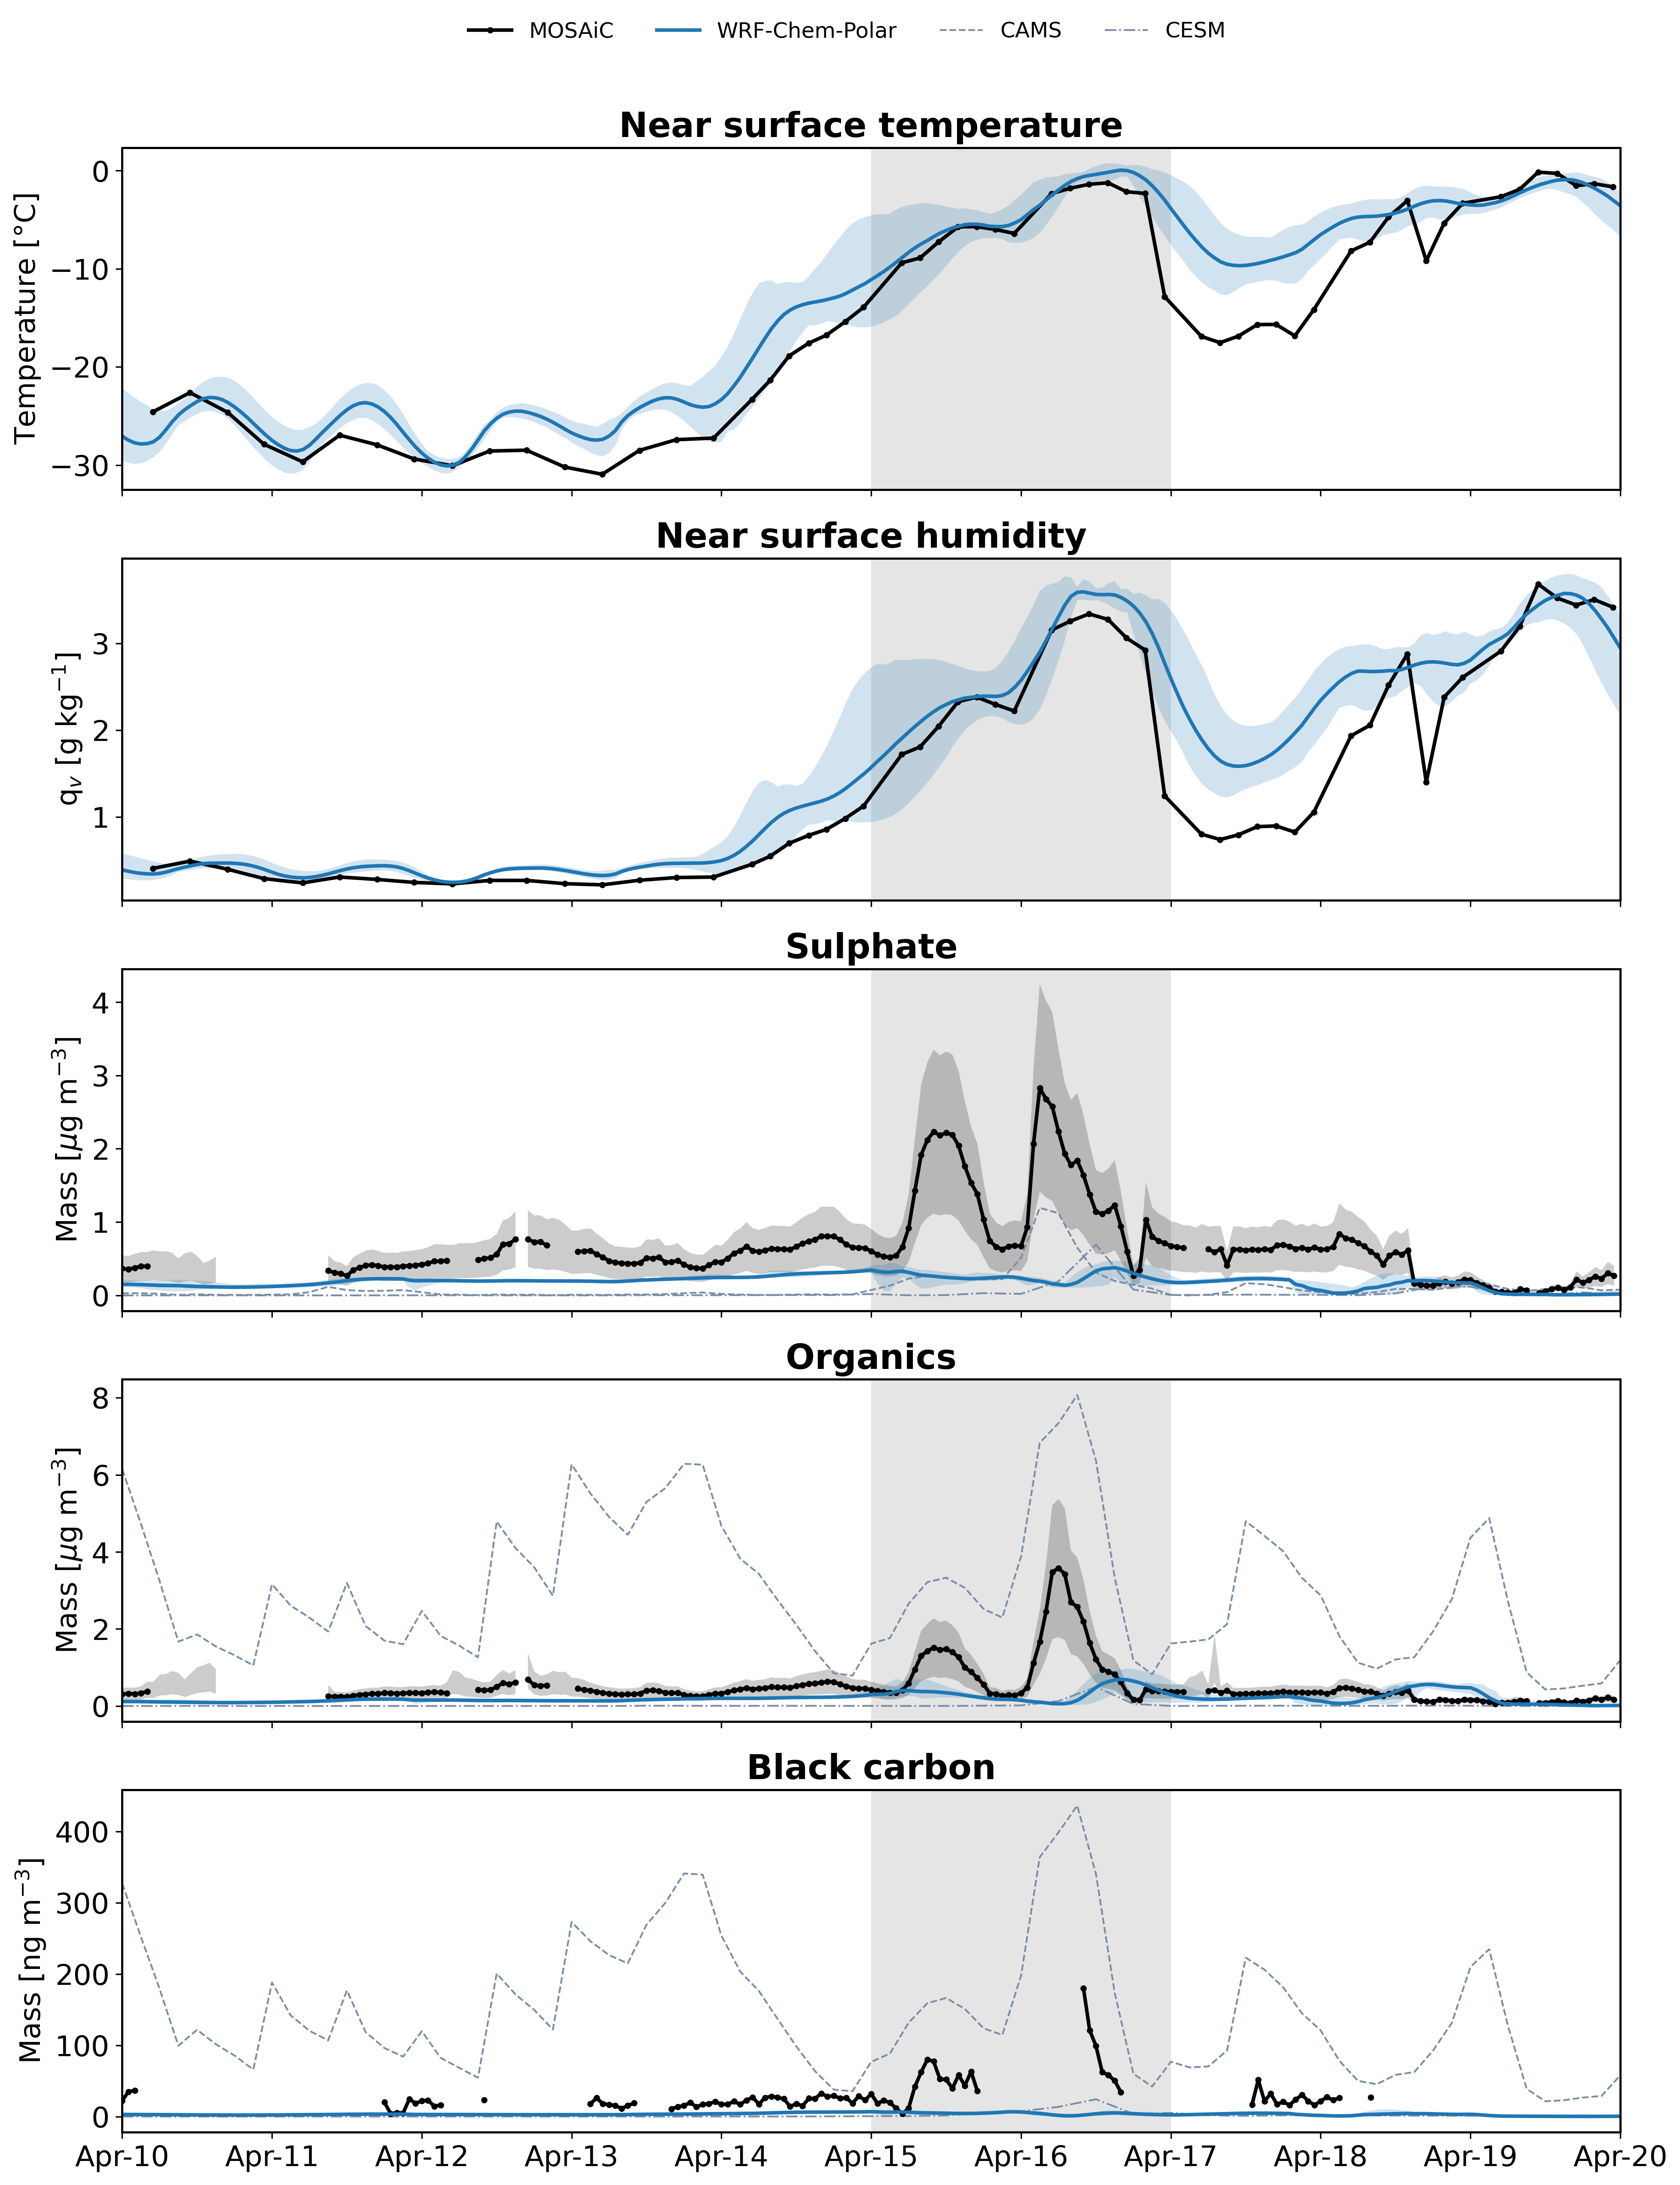

In [11]:
alpha, lw, ms = 0.1, 1, 5
c_input_data = "#7A8DA6"


fig, axes = plt.subplots(5, 1, figsize=(15,20), dpi=300)

for ax in axes:
    ax.axvspan(
        dt.datetime(2020,4,15),
        dt.datetime(2020,4,17),
        color="black",
        alpha=0.1,
        ec="None"
    )


### TEMPERATURE

axes[0].plot(
    mosaic_met.time,
    mosaic_met.t_10m,
    "k",
    marker=".",
    ms=ms,
    label="MOSAiC"
)
axes[0].plot(
    wrfout_mosaic_mean.Time,
    wrfout_mosaic_mean.air_temperature.isel(bottom_top=0)-273.15,
    c="tab:blue",
    label="WRF-Chem-Polar"
)
axes[0].fill_between(
    wrfout_mosaic_mean.Time,
    wrfout_mosaic_min.air_temperature.isel(bottom_top=0)-273.15,
    wrfout_mosaic_max.air_temperature.isel(bottom_top=0)-273.15,
    color="tab:blue",
    alpha=0.2,
    edgecolor="None"
)
axes[0].set_ylabel("Temperature [$\\degree$C]")
axes[0].set_title("Near surface temperature", weight="bold")


### HUMIDITY

axes[1].plot(
    mosaic_met.time,
    mosaic_met.r_10m,
    "k",
    marker=".",
    ms=ms
)
axes[1].plot(
    wrfout_mosaic_mean.Time,
    wrfout_mosaic_mean.QVAPOR.isel(bottom_top=0)*1e3,
    c="tab:blue",
)
axes[1].fill_between(
    wrfout_mosaic_mean.Time,
    wrfout_mosaic_min.QVAPOR.isel(bottom_top=0)*1e3,
    wrfout_mosaic_max.QVAPOR.isel(bottom_top=0)*1e3,
    color="tab:blue",
    alpha=0.2,
    edgecolor="None"
)
axes[1].set_ylabel("q$_v$ [g kg$^{{-1}}$]")
axes[1].set_title("Near surface humidity", weight="bold")


### AEROSOL MASS
f_ams = 0.65
std_ams = 0.5

# sulphate
lcams, = axes[2].plot(
    wrfout_mosaic_mean.Time,
    1e9*cams_mass_conc_mean.so4,
    c=c_input_data,
    ls="dashed",
    label="CAMS",
    linewidth=lw,
)
lcesm, = axes[2].plot(
    wrfout_mosaic_mean.Time,
    1e9*cesm_mass_conc_mean.so4.isel(lev=-1),
    c=c_input_data,
    ls="dashdot",
    label="CESM",
    linewidth=lw
)
axes[2].fill_between(
    ams_masked_1h.time,
    f_ams*ams_data_1h.so4-std_ams*f_ams*ams_data_1h.so4,
    f_ams*ams_data_1h.so4+std_ams*f_ams*ams_data_1h.so4,
    color="k",
    alpha=0.2,
    edgecolor="None"
)
lmosaic, = axes[2].plot(
    ams_masked_1h.time,
    f_ams*ams_masked_1h.so4,
    'k',
    label='MOSAiC',
    marker=".",
    ms=ms
)
lwrf, = axes[2].plot(
    wrfout_mosaic_mean.Time,
    wrfout_mosaic_mean.so4.isel(bottom_top=0),
    c="tab:blue",
    label="WRF-Chem-Polar"
)
axes[2].fill_between(
    wrfout_mosaic_mean.Time,
    wrfout_mosaic_min.so4.isel(bottom_top=0),
    wrfout_mosaic_max.so4.isel(bottom_top=0),
    color="tab:blue",
    alpha=0.2,
    edgecolor="None"
)
axes[2].set_ylabel("Mass [$\\mu$g m$^{{-3}}$]")
axes[2].set_title("Sulphate", weight="bold")

# oc
axes[3].plot(
    wrfout_mosaic_mean.Time,
    1e9*(cams_mass_conc_mean.oc_hydrophilic+cams_mass_conc_mean.oc_hydrophobic),
    c=c_input_data,
    ls="dashed",
    linewidth=lw,
    label="CAMS hydrophilic+hydrophobic"
)
axes[3].plot(
    wrfout_mosaic_mean.Time,
    1e9*cesm_mass_conc_mean.oc.isel(lev=-1),
    c=c_input_data,
    ls="dashdot",
    linewidth=lw,
)
axes[3].fill_between(
    ams_masked_1h.time,
    f_ams*ams_data_1h.org-std_ams*f_ams*ams_data_1h.org,
    f_ams*ams_data_1h.org+std_ams*f_ams*ams_data_1h.org,
    color="k",
    alpha=0.2,
    edgecolor="None"
)
axes[3].plot(
    ams_masked_1h.time,
    f_ams*ams_masked_1h.org,
    'k',
    marker=".",
    ms=ms
)
axes[3].fill_between(
    wrfout_mosaic_mean.Time,
    (wrfout_mosaic_min.toa+wrfout_mosaic_min.oc).isel(bottom_top=0),
    (wrfout_mosaic_max.toa+wrfout_mosaic_max.oc).isel(bottom_top=0),
    color="tab:blue",
    alpha=0.2,
    edgecolor="None"
)
axes[3].plot(
    wrfout_mosaic_mean.Time,
    (wrfout_mosaic_mean.toa+wrfout_mosaic_mean.oc).isel(bottom_top=0),
    c="tab:blue",
    label="WRF-Chem-Polar"
)
axes[3].set_ylabel("Mass [$\\mu$g m$^{{-3}}$]")
axes[3].set_title("Organics", weight="bold")

# bc

axes[4].plot(
    wrfout_mosaic_mean.Time,
    1e12*(cams_mass_conc_mean.bc_hydrophilic+cams_mass_conc_mean.bc_hydrophobic),
    c=c_input_data,
    label="CAMS all",
    ls="dashed",
    linewidth=lw
)
axes[4].plot(
    wrfout_mosaic_mean.Time,
    1e12*cesm_mass_conc_mean.bc.isel(lev=-1),
    c=c_input_data,
    ls="dashdot",
    linewidth=lw
)
axes[4].plot(
    ebc_masked_1h.time,
    f_ams*ebc_masked_1h,
    'k',
    marker=".",
    ms=ms
)
axes[4].plot(
    wrfout_mosaic_mean.Time,
    wrfout_mosaic_mean.bc.isel(bottom_top=0)*1e3,
    c="tab:blue",
    label="WRF-Chem-Polar"
)
axes[4].fill_between(
    wrfout_mosaic_mean.Time,
    wrfout_mosaic_min.bc.isel(bottom_top=0)*1e3,
    wrfout_mosaic_max.bc.isel(bottom_top=0)*1e3,
    color="tab:blue",
    alpha=0.2,
    edgecolor="None"
)
axes[4].set_ylabel("Mass [ng m$^{{-3}}$]")
axes[4].set_title("Black carbon", weight="bold")

fig.legend(
    ncols=4,
    handles=[lmosaic,lwrf,lcams,lcesm],
    loc="center",
    bbox_to_anchor=(0, 0.9, 1, 0.05),
    edgecolor="None",
    borderaxespad=0.25,
    fontsize=12
)
for ax in axes:
    ax.set_xlim(apr10_20.start, apr10_20.stop)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%d"))
for ax in axes[:-1]:
    ax.set_xticklabels([])

plt.savefig(f"../figures/figureA1.png", bbox_inches="tight")


## Figure A2

### Process data into dataframe that plot function can read

In [12]:
bg = slice(dt.datetime(2020,4,1), dt.datetime(2020,4,13,23,59))
wai = slice(dt.datetime(2020,4,15), dt.datetime(2020,4,16,23,59))

wai_state = []
for time in wrfout_cld.Time.values:
    time = pd.Timestamp(time)
    if time>=bg.start and time<=bg.stop:
        wai_state.append("background")
    elif time>=wai.start and time<=wai.stop:
        wai_state.append("WAI")
    else:
        wai_state.append("unclassed")
wrfout_cld = wrfout_cld.assign_coords({
    "wai_state":("Time",wai_state),
})

plot_colours = {
    "polluted": "tab:blue",
    "clean": "grey",
}

data = wrfout_cld.sel(Time=wrfout_cld.wai_state!="unclassed").to_dataframe()
medians = data.groupby(['wai_state','pollution_state']).median()
means = data.groupby(['wai_state','pollution_state']).mean()


### Make figure

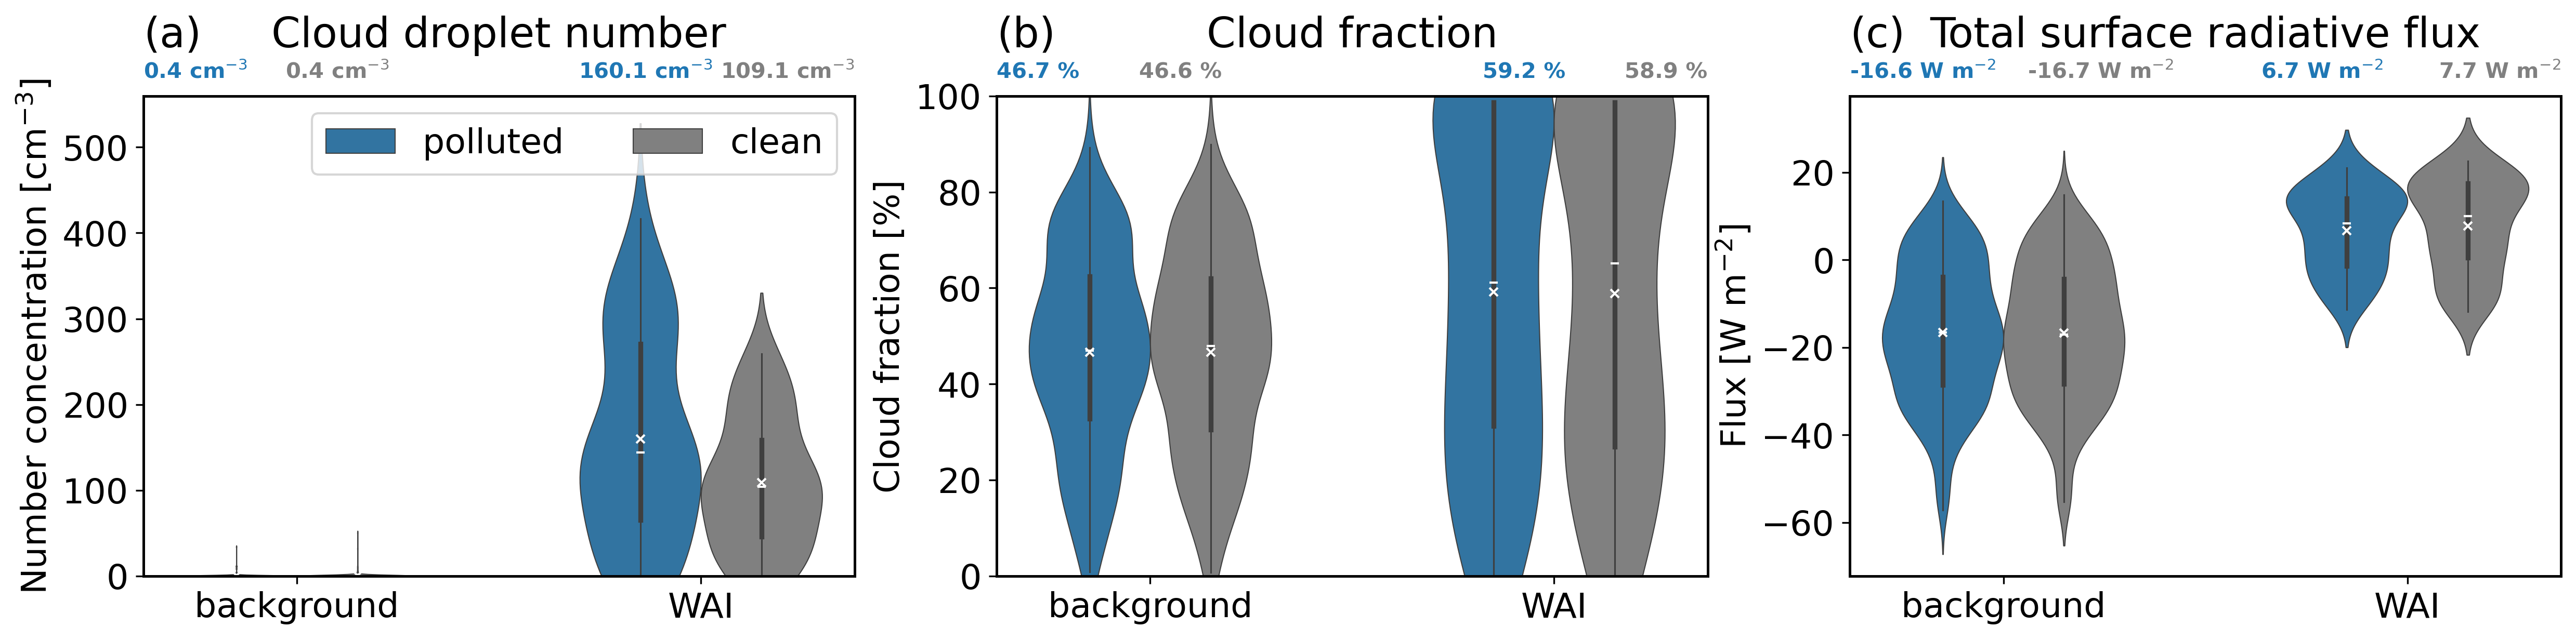

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(20,4), dpi=300)
fs_label = 10
### CDNC

stats_cdnc = medians["cdnc"]
means_cdnc = means["cdnc"]
axes[0].text(
    s=f"{means_cdnc['background']['polluted']:.1f} cm$^{{-3}}$",
    y=1.05, x=0, ha="left", va="center",
    transform=axes[0].transAxes,
    color=plot_colours["polluted"],
    weight="bold",
    fontsize=fs_label,
)
axes[0].text(
    s=f"{means_cdnc['background']['clean']:.1f} cm$^{{-3}}$",
    y=1.05, x=0.2, ha="left", va="center",
    transform=axes[0].transAxes,
    color=plot_colours["clean"],
    weight="bold",
    fontsize=fs_label,
)
axes[0].text(
    s=f"{means_cdnc['WAI']['polluted']:.1f} cm$^{{-3}}$",
    y=1.05, x=0.8, ha="right", va="center",
    transform=axes[0].transAxes,
    color=plot_colours["polluted"],
    weight="bold",
    fontsize=fs_label,
)
axes[0].text(
    s=f"{means_cdnc['WAI']['clean']:.1f} cm$^{{-3}}$",
    y=1.05, x=1, ha="right", va="center",
    transform=axes[0].transAxes,
    color=plot_colours["clean"],
    weight="bold",
    fontsize=fs_label,
)
# plot
sns.violinplot(
    data=data,
    x="wai_state",
    y="cdnc",
    hue="pollution_state",
    ax=axes[0],
    linewidth=0.5,
    width=0.6,
    common_norm=True,
    density_norm="width",
    palette=plot_colours,
)
axes[0].plot(
    [-0.15, 0.15, 0.85, 1.15],
    [
        means_cdnc['background']['polluted'],
        means_cdnc['background']['clean'],
        means_cdnc['WAI']['polluted'],
        means_cdnc['WAI']['clean'],
    ],
    "wx",
    ms=4
)
axes[0].plot(
    [-0.15, 0.15, 0.85, 1.15],
    [
        stats_cdnc['background']['polluted'],
        stats_cdnc['background']['clean'],
        stats_cdnc['WAI']['polluted'],
        stats_cdnc['WAI']['clean'],
    ],
    "w_",
    ms=4
)
axes[0].set_title("Cloud droplet number", y=1.075)
axes[0].set_ylabel("Number concentration [cm$^{{-3}}$]")
axes[0].set_xlabel("")
axes[0].set_ylim(bottom=0)

### CLOUD FRACTION

stats_cf = medians["clt_2km"]
means_cf = means["clt_2km"]
axes[1].text(
    s=f"{means_cf['background']['polluted']:.1f} %",
    y=1.05, x=0, ha="left", va="center",
    transform=axes[1].transAxes,
    color=plot_colours["polluted"],
    weight="bold",
    fontsize=fs_label,
)
axes[1].text(
    s=f"{means_cf['background']['clean']:.1f} %",
    y=1.05, x=0.2, ha="left", va="center",
    transform=axes[1].transAxes,
    color=plot_colours["clean"],
    weight="bold",
    fontsize=fs_label,
)
axes[1].text(
    s=f"{means_cf['WAI']['polluted']:.1f} %",
    y=1.05, x=0.8, ha="right", va="center",
    transform=axes[1].transAxes,
    color=plot_colours["polluted"],
    weight="bold",
    fontsize=fs_label,
)
axes[1].text(
    s=f"{means_cf['WAI']['clean']:.1f} %",
    y=1.05, x=1, ha="right", va="center",
    transform=axes[1].transAxes,
    color=plot_colours["clean"],
    weight="bold",
    fontsize=fs_label,
)
# plot
sns.violinplot(
    data=data,
    x="wai_state",
    y="clt_2km",
    hue="pollution_state",
    ax=axes[1],
    linewidth=0.5,
    width=0.6,
    common_norm=True,
    density_norm="width",
    legend=False,
    palette=plot_colours,
)
axes[1].plot(
    [-0.15, 0.15, 0.85, 1.15],
    [
        means_cf['background']['polluted'],
        means_cf['background']['clean'],
        means_cf['WAI']['polluted'],
        means_cf['WAI']['clean'],
    ],
    "wx",
    ms=4
)
axes[1].plot(
    [-0.15, 0.15, 0.85, 1.15],
    [
        stats_cf['background']['polluted'],
        stats_cf['background']['clean'],
        stats_cf['WAI']['polluted'],
        stats_cf['WAI']['clean'],
    ],
    "w_",
    ms=4
)
axes[1].set_title("Cloud fraction", y=1.075)
axes[1].set_ylabel("Cloud fraction [%]")
axes[1].set_xlabel("")
axes[1].set_ylim(0,100)

### SURFACE RAD FLUX

stats_rad = medians["sfc_rad"]
means_rad = means["sfc_rad"]
axes[2].text(
    s=f"{means_rad['background']['polluted']:.1f} W m$^{{-2}}$",
    y=1.05, x=0, ha="left", va="center",
    transform=axes[2].transAxes,
    color=plot_colours["polluted"],
    weight="bold",
    fontsize=fs_label,
)
axes[2].text(
    s=f"{means_rad['background']['clean']:.1f} W m$^{{-2}}$",
    y=1.05, x=0.25, ha="left", va="center",
    transform=axes[2].transAxes,
    color=plot_colours["clean"],
    weight="bold",
    fontsize=fs_label,
)
axes[2].text(
    s=f"{means_rad['WAI']['polluted']:.1f} W m$^{{-2}}$",
    y=1.05, x=0.75, ha="right", va="center",
    transform=axes[2].transAxes,
    color=plot_colours["polluted"],
    weight="bold",
    fontsize=fs_label,
)
axes[2].text(
    s=f"{means_rad['WAI']['clean']:.1f} W m$^{{-2}}$",
    y=1.05, x=1, ha="right", va="center",
    transform=axes[2].transAxes,
    color=plot_colours["clean"],
    weight="bold",
    fontsize=fs_label,
)
# plot
sns.violinplot(
    data=data,
    x="wai_state",
    y="sfc_rad",
    hue="pollution_state",
    ax=axes[2],
    linewidth=0.5,
    width=0.6,
    common_norm=True,
    density_norm="width",
    legend=False,
    palette=plot_colours,
)
axes[2].plot(
    [-0.15, 0.15, 0.85, 1.15],
    [
        means_rad['background']['polluted'],
        means_rad['background']['clean'],
        means_rad['WAI']['polluted'],
        means_rad['WAI']['clean'],
    ],
    "wx",
    ms=4
)
axes[2].plot(
    [-0.15, 0.15, 0.85, 1.15],
    [
        stats_rad['background']['polluted'],
        stats_rad['background']['clean'],
        stats_rad['WAI']['polluted'],
        stats_rad['WAI']['clean'],
    ],
    "w_",
    ms=4
)
axes[2].set_title("Total surface radiative flux", y=1.075)
axes[2].set_ylabel("Flux [W m$^{{-2}}$]")
axes[2].set_xlabel("")

axes[0].legend(ncols=2)
for i in range(len(axes)):
    axes[i].set_title(f"({string.ascii_lowercase[i]})", y=1.075, loc="left")
plt.savefig("../figures/figureA2.png", bbox_inches="tight")